# Pre-Harvest Agricultural Forecasting: A Predictive Model for Palay Yields
**By:** Luke Joaquin Bernardo  
**Institution:** Jose Rizal University  
**Alignment:** SDG 2: Zero Hunger — Target 2.4  
**Data Source:** Philippine Statistics Authority (PSA) — OpenSTAT Portal  

---

## Project Overview

The Philippines produced **20.06 million metric tons** of palay in 2023, yet supply remains dangerously concentrated — just two regions (Central Luzon and Cagayan Valley) account for 33% of the national rice supply. Combined with climate volatility from El Niño and soaring fertilizer costs, the risk of regional shortages triggering national price spikes is real.

**Objective:** Build a pre-harvest forecasting model that predicts the exact volume of palay production (in metric tons) using inputs available at the *start* of the season — enabling government safety nets to be triggered *before* shortages materialize.

---

## Model Strategy

Since our target variable (Volume of Production) is **continuous**, this is a **regression problem** — not a classification problem. The models we will build and compare are:

| Model | Why It's Applicable |
|---|---|
| **Multiple Linear Regression (MLR)** | Primary model per proposal; fully interpretable coefficients; suitable for continuous targets |
| **Support Vector Regression (SVR)** | SVM applied to regression; robust to outliers; works well with structured numerical data |
| **Decision Tree Regressor** | Non-linear splits; easy to interpret; baseline tree model |
| **Random Forest Regressor** | Ensemble of trees; reduces overfitting; strongest generalization |

All models will be evaluated using **K-Fold Cross Validation** and **GridSearchCV fine-tuning**.

---

## Notebook Structure

1. Import Libraries
2. Load and Inspect the Raw Datasets
3. Data Wrangling — Reshape and Merge
4. Feature Engineering and Label Encoding
5. Exploratory Data Analysis (EDA)
6. Prepare Features and Target
7. Model 1: Multiple Linear Regression (MLR)
8. Model 2: Support Vector Regression (SVR)
9. Model 3: Decision Tree Regressor
10. Model 4: Random Forest Regressor
11. Model Comparison
12. Sample Prediction (Pre-Harvest Simulation)

---
## Cell 1 — Import Libraries

**What this cell does:** Loads all the Python libraries needed for the entire notebook.

**Why each library:**
- `pandas` — reads and manipulates tabular data (our CSVs)
- `numpy` — numerical operations (array math, random seeds)
- `matplotlib` and `seaborn` — visualizations (charts, heatmaps)
- `sklearn` — the machine learning toolkit; contains all four regression models, cross-validation, scaling, and GridSearchCV
- `warnings` — suppresses minor convergence warnings that clutter output

In [ ]:
# Standard data handling libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # Suppress convergence/future warnings for cleaner output

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn: Preprocessing ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder converts categorical text (e.g. 'Irrigated'/'Rainfed') to numbers (0/1)
# StandardScaler normalizes feature values — important for SVR which is distance-based

# --- Scikit-learn: Model Selection ---
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
# KFold: splits data into K equal parts for robust evaluation
# cross_val_score: runs the model K times and returns accuracy per fold
# GridSearchCV: exhaustively tests hyperparameter combinations to find the best settings
# train_test_split: for a final held-out test set evaluation

# --- Scikit-learn: Regression Models ---
from sklearn.linear_model import LinearRegression
# Multiple Linear Regression — primary model from the project proposal

from sklearn.svm import SVR
# Support Vector Regression — SVM adapted for continuous output

from sklearn.tree import DecisionTreeRegressor
# Decision Tree Regressor — tree-based, non-linear regression

from sklearn.ensemble import RandomForestRegressor
# Random Forest — ensemble of decision trees; strongest generalization

# --- Scikit-learn: Metrics ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# R² (R-squared): how much variance the model explains (1.0 = perfect)
# MAE (Mean Absolute Error): average absolute prediction error in metric tons
# RMSE (Root Mean Squared Error): penalizes large errors more heavily than MAE

# --- Scikit-learn: Pipeline ---
from sklearn.pipeline import Pipeline
# Pipeline: chains scaling + model into one object — prevents data leakage during CV

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## Cell 2 — Load and Inspect the Raw Datasets

**What this cell does:** Reads the three PSA CSV files and displays their basic structure.

**Why `skiprows=1`:**  
Each CSV has a long title string on the first row (e.g., *'Palay and Corn: Area Harvested...'*). The actual column headers (like `Ecosystem/Croptype`, `Geolocation`, `2003 Quarter 1`) are on the **second row**. We skip the first row so pandas treats row 2 as the header.

**Dataset structure:**
- **Area Harvested** and **Volume of Production** are in **wide format** — rows are province × ecosystem combinations, columns are time periods (Year + Quarter)
- **Fertilizer** is also wide format — rows are region × fertilizer type, columns are years

We need to reshape (melt) these into long format before merging.

In [ ]:
area_raw = pd.read_csv('/content/The Area Harvested Dataset.csv', skiprows=1)
prod_raw = pd.read_csv('/content/The Volume of Production Dataset.csv', skiprows=1)
fert_raw = pd.read_csv('/content/The Fertilizer Dataset.csv', skiprows=1)

# --- Inspect Area Harvested ---
print("=" * 60)
print("AREA HARVESTED (Hectares)")
print(f"Shape: {area_raw.shape[0]} rows × {area_raw.shape[1]} columns")
print("First 3 columns:", area_raw.columns[:3].tolist())
print("Last 3 columns:", area_raw.columns[-3:].tolist())
print()
display(area_raw.iloc[:3, :5])  # Show first 3 rows, first 5 columns for readability

# --- Inspect Volume of Production ---
print("=" * 60)
print("VOLUME OF PRODUCTION (Metric Tons)")
print(f"Shape: {prod_raw.shape[0]} rows × {prod_raw.shape[1]} columns")
print()
display(prod_raw.iloc[:3, :5])

# --- Inspect Fertilizer ---
print("=" * 60)
print("FERTILIZER USE (kg/ha by type)")
print(f"Shape: {fert_raw.shape[0]} rows × {fert_raw.shape[1]} columns")
print()
display(fert_raw)

# --- Confirm ecosystem categories ---
print("=" * 60)
print("Unique Ecosystem Types:", area_raw['Ecosystem/Croptype'].unique().tolist())
print("Unique Provinces (Geolocation):", area_raw['Geolocation'].unique().tolist())

AREA HARVESTED (Hectares)
Shape: 24 rows × 90 columns
First 3 columns: ['Ecosystem/Croptype', 'Geolocation', '2003 Quarter 1']
Last 3 columns: ['2024 Quarter 2', '2024 Quarter 3', '2024 Quarter 4']



,Ecosystem/Croptype,Geolocation,2003 Quarter 1,2003 Quarter 2,2003 Quarter 3
0,Irrigated Palay,....Batanes,0.0,0.0,0.0
1,Irrigated Palay,....Cagayan,26019.0,35650.0,12908.0
2,Irrigated Palay,....Isabela,79587.0,50875.0,9736.0


VOLUME OF PRODUCTION (Metric Tons)
Shape: 24 rows × 90 columns



,Ecosystem/Croptype,Geolocation,2003 Quarter 1,2003 Quarter 2,2003 Quarter 3
0,Irrigated Palay,....Batanes,0.0,0.0,0.0
1,Irrigated Palay,....Cagayan,88278.0,126593.0,44016.0
2,Irrigated Palay,....Isabela,342224.0,195300.0,40112.0


FERTILIZER USE (kg/ha by type)
Shape: 6 rows × 24 columns



,Geolocation,Fertilizer,2003,2004,2005,2006,2007,2008,2009,2010,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,..REGION II (CAGAYAN VALLEY),Urea,2.53,2.37,2.49,2.45,2.58,2.63,2.91,2.77,...,3.27,3.37,3.03,3.06,3.17,3.19,3.38,2.34,2.61,2.89
1,..REGION II (CAGAYAN VALLEY),Ammosul,0.18,0.18,0.29,0.31,0.36,0.40,0.40,0.48,...,0.47,0.37,0.44,0.45,0.32,0.23,0.32,1.00,0.78,0.75
2,..REGION II (CAGAYAN VALLEY),Complete,1.21,1.41,1.44,1.06,1.04,1.19,1.40,1.34,...,1.60,1.89,1.77,1.89,1.88,1.88,2.44,1.42,1.40,1.56
3,..REGION III (CENTRAL LUZON),Urea,2.47,2.31,2.31,2.28,1.98,2.01,2.35,2.46,...,2.67,2.74,2.80,2.86,2.88,3.11,3.12,3.22,3.19,3.07
4,..REGION III (CENTRAL LUZON),Ammosul,0.35,0.38,0.32,0.41,0.56,0.69,0.51,0.53,...,0.27,0.46,0.27,0.21,0.36,0.25,0.78,0.87,0.66,0.66
5,..REGION III (CENTRAL LUZON),Complete,2.33,2.67,2.14,2.33,2.05,1.98,2.27,2.32,...,2.78,2.72,2.66,2.98,2.86,3.37,3.18,2.57,2.51,3.34


Unique Ecosystem Types: ['Irrigated Palay', 'Rainfed Palay']
Unique Provinces (Geolocation): ['....Batanes', '....Cagayan', '....Isabela', '....Nueva Vizcaya', '....Quirino', '....Aurora', '....Bataan', '....Bulacan', '....Nueva Ecija', '....Pampanga', '....Tarlac', '....Zambales']


---
## Cell 3 — Data Wrangling: Reshape from Wide to Long Format

**What this cell does:** Transforms the three wide-format tables into a single long-format dataset with one row per observation (province × ecosystem × year × quarter).

**Why reshape (melt)?**  
Machine learning models expect data in **long format** — each row is one observation, each column is one feature. The raw CSVs spread time periods across columns (wide format), which is good for spreadsheets but not for ML.

**Why a region map?**  
The fertilizer dataset is organized at the **regional level** (Region II, Region III), while area harvested and production are at the **provincial level**. We need to map each province to its region so we can join the fertilizer data correctly.

**Final result:** 2,112 rows × 11 columns — one row per province-ecosystem-quarter combination.

In [ ]:
# ---------------------------------------------------------------
# STEP 1: Identify the quarter columns in area & production tables
# These are all columns that contain the word 'Quarter'
# ---------------------------------------------------------------
quarter_cols = [c for c in area_raw.columns if 'Quarter' in c]
print(f"Found {len(quarter_cols)} quarterly periods: {quarter_cols[:3]} ... {quarter_cols[-2:]}")

# ---------------------------------------------------------------
# STEP 2: Melt Area Harvested — wide → long
# id_vars: columns to keep as-is (ecosystem type and province)
# value_vars: the time period columns to unpivot
# var_name: the new column name for the period label
# value_name: the new column name for the actual hectare value
# ---------------------------------------------------------------
area_long = area_raw.melt(
    id_vars=['Ecosystem/Croptype', 'Geolocation'],
    value_vars=quarter_cols,
    var_name='Period',
    value_name='Area_Harvested'
)

# ---------------------------------------------------------------
# STEP 3: Melt Volume of Production — same logic
# ---------------------------------------------------------------
prod_long = prod_raw.melt(
    id_vars=['Ecosystem/Croptype', 'Geolocation'],
    value_vars=quarter_cols,
    var_name='Period',
    value_name='Volume_Production'
)

# ---------------------------------------------------------------
# STEP 4: Extract Year and Quarter number from the Period string
# '2003 Quarter 1' → Year=2003, Quarter=1
# .str.extract() uses regex to pull the 4-digit year and single-digit quarter
# ---------------------------------------------------------------
for df in [area_long, prod_long]:
    df['Year']    = df['Period'].str.extract(r'(\d{4})').astype(int)
    df['Quarter'] = df['Period'].str.extract(r'Quarter (\d)').astype(int)

# ---------------------------------------------------------------
# STEP 5: Melt Fertilizer data — wide → long, then pivot by type
# The fertilizer table has separate rows per type (Urea, Ammosul, Complete)
# We melt it first, then pivot so each type becomes its own column
# ---------------------------------------------------------------
year_cols = [c for c in fert_raw.columns if c not in ['Geolocation', 'Fertilizer']]
fert_long = fert_raw.melt(
    id_vars=['Geolocation', 'Fertilizer'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)
fert_long['Year'] = fert_long['Year'].astype(int)

# Pivot: rows = region+year, columns = fertilizer types
fert_pivot = fert_long.pivot_table(
    index=['Geolocation', 'Year'],
    columns='Fertilizer',
    values='Value'
).reset_index()
fert_pivot.columns.name = None  # Remove the 'Fertilizer' label from column axis

# ---------------------------------------------------------------
# STEP 6: Map each province to its PSA region
# Region II (Cagayan Valley): Batanes, Cagayan, Isabela, Nueva Vizcaya, Quirino
# Region III (Central Luzon): Aurora, Bataan, Bulacan, Nueva Ecija, Pampanga, Tarlac, Zambales
# ---------------------------------------------------------------
region_map = {
    '....Batanes':       '..REGION II (CAGAYAN VALLEY)',
    '....Cagayan':       '..REGION II (CAGAYAN VALLEY)',
    '....Isabela':       '..REGION II (CAGAYAN VALLEY)',
    '....Nueva Vizcaya': '..REGION II (CAGAYAN VALLEY)',
    '....Quirino':       '..REGION II (CAGAYAN VALLEY)',
    '....Aurora':        '..REGION III (CENTRAL LUZON)',
    '....Bataan':        '..REGION III (CENTRAL LUZON)',
    '....Bulacan':       '..REGION III (CENTRAL LUZON)',
    '....Nueva Ecija':   '..REGION III (CENTRAL LUZON)',
    '....Pampanga':      '..REGION III (CENTRAL LUZON)',
    '....Tarlac':        '..REGION III (CENTRAL LUZON)',
    '....Zambales':      '..REGION III (CENTRAL LUZON)',
}
area_long['Region'] = area_long['Geolocation'].map(region_map)
prod_long['Region'] = prod_long['Geolocation'].map(region_map)

# ---------------------------------------------------------------
# STEP 7: Merge Area + Production on matching keys
# Both tables share: Ecosystem, Geolocation, Year, Quarter
# ---------------------------------------------------------------
df = pd.merge(
    area_long,
    prod_long[['Ecosystem/Croptype', 'Geolocation', 'Year', 'Quarter', 'Volume_Production']],
    on=['Ecosystem/Croptype', 'Geolocation', 'Year', 'Quarter']
)

# ---------------------------------------------------------------
# STEP 8: Merge Fertilizer using Region + Year
# Fertilizer data is at regional level, so we join on Region (not province)
# ---------------------------------------------------------------
df = pd.merge(
    df,
    fert_pivot,
    left_on=['Region', 'Year'],
    right_on=['Geolocation', 'Year'],
    how='left'
)
# Drop the duplicate Geolocation column from the fertilizer table
df = df.drop(columns=['Geolocation_y']).rename(columns={'Geolocation_x': 'Geolocation'})

# ---------------------------------------------------------------
# STEP 9: Verify the final merged dataset
# ---------------------------------------------------------------
print("\nFinal Merged Dataset")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print()
display(df.head())

Found 88 quarterly periods: ['2003 Quarter 1', '2003 Quarter 2', '2003 Quarter 3'] ... ['2024 Quarter 3', '2024 Quarter 4']

Final Merged Dataset
Shape: 2112 rows × 11 columns

Columns: ['Ecosystem/Croptype', 'Geolocation', 'Period', 'Area_Harvested', 'Year', 'Quarter', 'Region', 'Volume_Production', 'Ammosul', 'Complete', 'Urea']

Missing values:
Ecosystem/Croptype    0
Geolocation           0
Period                0
Area_Harvested        0
Year                  0
Quarter               0
Region                0
Volume_Production     0
Ammosul               0
Complete              0
Urea                  0
dtype: int64



,Ecosystem/Croptype,Geolocation,Period,Area_Harvested,Year,Quarter,Region,Volume_Production,Ammosul,Complete,Urea
0,Irrigated Palay,....Batanes,2003 Quarter 1,0.0,2003,1,..REGION II (CAGAYAN VALLEY),0.0,0.18,1.21,2.53
1,Irrigated Palay,....Cagayan,2003 Quarter 1,26019.0,2003,1,..REGION II (CAGAYAN VALLEY),88278.0,0.18,1.21,2.53
2,Irrigated Palay,....Isabela,2003 Quarter 1,79587.0,2003,1,..REGION II (CAGAYAN VALLEY),342224.0,0.18,1.21,2.53
3,Irrigated Palay,....Nueva Vizcaya,2003 Quarter 1,12700.0,2003,1,..REGION II (CAGAYAN VALLEY),47625.0,0.18,1.21,2.53
4,Irrigated Palay,....Quirino,2003 Quarter 1,4614.0,2003,1,..REGION II (CAGAYAN VALLEY),15365.0,0.18,1.21,2.53


---
## Cell 4 — Feature Engineering and Label Encoding

**What this cell does:** Prepares the final feature set exactly as defined in the project proposal, and encodes the categorical `Ecosystem` column.

**Why Label Encoding for Ecosystem?**  
The `Ecosystem/Croptype` column contains two text values: `'Irrigated Palay'` and `'Rainfed Palay'`. Machine learning models cannot work with raw text — they need numbers. Label Encoding converts these to **0 and 1**, which is appropriate here because there are only two categories (binary), making it equivalent to a simple dummy variable.

**Why drop the Period, Geolocation, Region columns?**  
- `Period` is redundant — it's already split into `Year` and `Quarter`
- `Geolocation` and `Region` are identifiers, not predictive features; including them would cause the model to overfit to specific provinces rather than learning generalizable patterns

**Final Features (X) matching the proposal formula:**
- X₁ = Area_Harvested (hectares)
- X₂ = Urea (kg/ha)
- X₃ = Ammosul (kg/ha)
- X₄ = Ecosystem (0=Irrigated, 1=Rainfed)
- X₅ = Complete/14-14-14 (kg/ha)
- X₆ = Quarter (1–4, seasonality proxy)

In [ ]:
# ---------------------------------------------------------------
# STEP 1: Label Encode the Ecosystem column
# LabelEncoder assigns: 'Irrigated Palay' = 0, 'Rainfed Palay' = 1
# (alphabetical order by default)
# ---------------------------------------------------------------
le = LabelEncoder()
df['Ecosystem'] = le.fit_transform(df['Ecosystem/Croptype'])

# Verify the encoding
print("Label Encoding Applied:")
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  '{label}' → {code}")

# ---------------------------------------------------------------
# STEP 2: Select only the 6 model features + target variable
# This matches the project proposal formula exactly:
# Y = β0 + β1(Hectares) + β2(Urea) + β3(Ammosul) +
#         β4(Ecosystem) + β5(Complete) + β6(Quarter) + ε
# ---------------------------------------------------------------
feature_cols = [
    'Area_Harvested',  # X1 — Total land area harvested (hectares)
    'Urea',            # X2 — Urea fertilizer applied (kg/ha)
    'Ammosul',         # X3 — Ammonium sulfate applied (kg/ha)
    'Ecosystem',       # X4 — 0=Irrigated, 1=Rainfed
    'Complete',        # X5 — 14-14-14 complete fertilizer (kg/ha)
    'Quarter'          # X6 — Harvest quarter (1-4, seasonality proxy)
]
target_col = 'Volume_Production'  # Y — Volume of production (metric tons)

# ---------------------------------------------------------------
# STEP 3: Extract clean feature matrix and target vector
# ---------------------------------------------------------------
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\nFeature matrix X: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Target vector y: {y.shape[0]} values")
print(f"\nTarget variable statistics:")
print(y.describe().apply(lambda v: f"{v:,.2f}"))

# ---------------------------------------------------------------
# STEP 4: Summary of feature statistics
# ---------------------------------------------------------------
print("\nFeature Summary:")
display(X.describe().round(2))

Label Encoding Applied:
  'Irrigated Palay' → 0
  'Rainfed Palay' → 1

Feature matrix X: 2112 rows × 6 features
Target vector y: 2112 values

Target variable statistics:
count      2,112.00
mean      57,903.81
std      113,628.44
min            0.00
25%          257.75
50%       15,064.50
75%       57,668.75
max      820,877.00
Name: Volume_Production, dtype: object

Feature Summary:


,Area_Harvested,Urea,Ammosul,Ecosystem,Complete,Quarter
count,2112.00,2112.00,2112.00,2112.0,2112.00,2112.00
mean,12803.58,2.71,0.45,0.5,2.15,2.50
std,22464.58,0.37,0.18,0.5,0.65,1.12
min,0.00,1.98,0.18,0.0,1.04,1.00
25%,89.25,2.42,0.32,0.0,1.49,1.75
50%,3962.50,2.71,0.40,0.5,2.27,2.50
75%,14105.50,3.06,0.53,1.0,2.66,3.25
max,130169.00,3.38,1.00,1.0,3.37,4.00


---
## Cell 5 — Exploratory Data Analysis (EDA)

**What this cell does:** Visualizes the data to understand distributions, relationships, and patterns before modeling.

**Why EDA before modeling?**  
- Reveals if the target variable is skewed (affects model choice)
- Shows which features are most correlated with production volume (guides interpretation)
- Identifies potential outliers or anomalies in the data
- Provides visual evidence that supports the proposal's narrative (e.g., irrigated vs. rainfed differences)

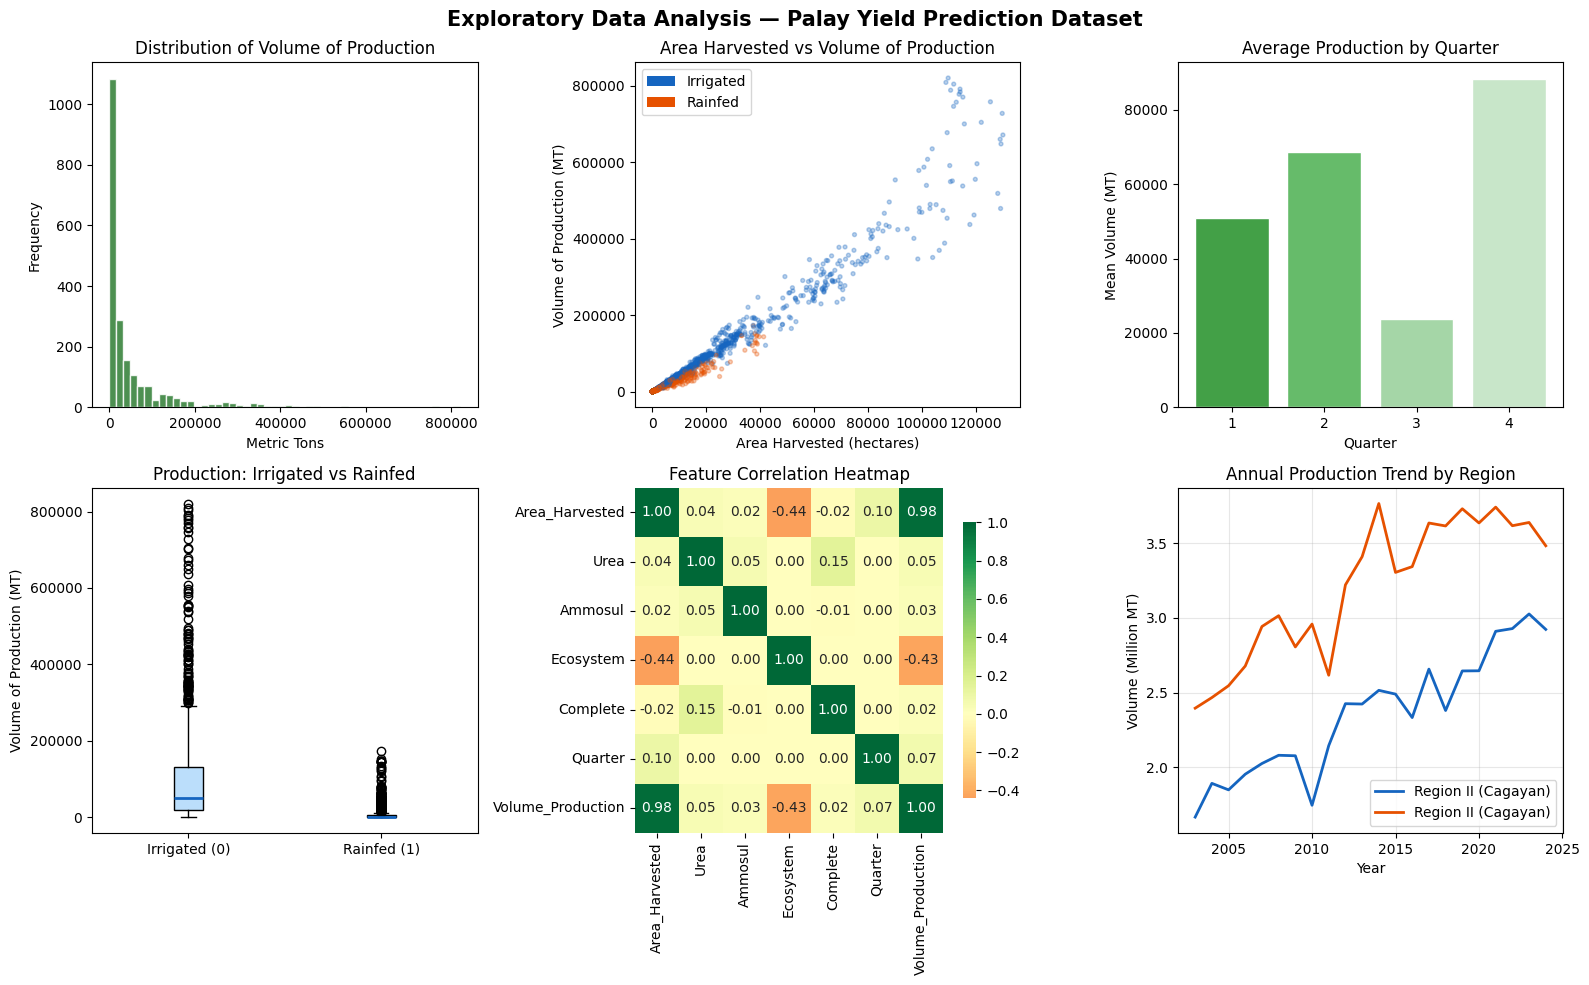

EDA complete.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — Palay Yield Prediction Dataset', fontsize=15, fontweight='bold')

# ---------------------------------------------------------------
# Plot 1: Distribution of Volume of Production (Target Variable)
# Why: We want to see if the target is roughly normal or skewed.
# Skewed targets may benefit from log transformation.
# ---------------------------------------------------------------
axes[0, 0].hist(y, bins=50, color='#2e7d32', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Distribution of Volume of Production')
axes[0, 0].set_xlabel('Metric Tons')
axes[0, 0].set_ylabel('Frequency')

# ---------------------------------------------------------------
# Plot 2: Area Harvested vs Volume of Production
# Why: Area harvested is expected to be the strongest predictor.
# This scatter shows if the relationship is linear.
# ---------------------------------------------------------------
colors = ['#1565c0' if e == 0 else '#e65100' for e in X['Ecosystem']]
axes[0, 1].scatter(X['Area_Harvested'], y, c=colors, alpha=0.3, s=8)
axes[0, 1].set_title('Area Harvested vs Volume of Production')
axes[0, 1].set_xlabel('Area Harvested (hectares)')
axes[0, 1].set_ylabel('Volume of Production (MT)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1565c0', label='Irrigated'), Patch(facecolor='#e65100', label='Rainfed')]
axes[0, 1].legend(handles=legend_elements)

# ---------------------------------------------------------------
# Plot 3: Production by Quarter (Seasonality)
# Why: Quarter is our seasonality proxy. This shows if certain
# quarters systematically produce more palay.
# ---------------------------------------------------------------
df_plot = df.copy()
df_plot['Ecosystem'] = df['Ecosystem/Croptype']  # Use readable label for plot
quarter_means = df_plot.groupby('Quarter')['Volume_Production'].mean()
axes[0, 2].bar(quarter_means.index, quarter_means.values, color=['#43a047','#66bb6a','#a5d6a7','#c8e6c9'], edgecolor='white')
axes[0, 2].set_title('Average Production by Quarter')
axes[0, 2].set_xlabel('Quarter')
axes[0, 2].set_ylabel('Mean Volume (MT)')
axes[0, 2].set_xticks([1, 2, 3, 4])

# ---------------------------------------------------------------
# Plot 4: Irrigated vs Rainfed Production (Boxplot)
# Why: Validates the label encoding decision. If irrigated and
# rainfed produce significantly different volumes, the binary
# Ecosystem feature will be informative for the model.
# ---------------------------------------------------------------
eco_groups = [df[df['Ecosystem/Croptype'] == 'Irrigated Palay']['Volume_Production'],
              df[df['Ecosystem/Croptype'] == 'Rainfed Palay']['Volume_Production']]
axes[1, 0].boxplot(eco_groups, labels=['Irrigated (0)', 'Rainfed (1)'], patch_artist=True,
                   boxprops=dict(facecolor='#bbdefb'), medianprops=dict(color='#1565c0', linewidth=2))
axes[1, 0].set_title('Production: Irrigated vs Rainfed')
axes[1, 0].set_ylabel('Volume of Production (MT)')

# ---------------------------------------------------------------
# Plot 5: Correlation Heatmap
# Why: Shows which features are most correlated with the target
# and with each other (multicollinearity check for MLR).
# High correlation between features (e.g., Urea and Ammosul)
# can cause instability in linear regression coefficients.
# ---------------------------------------------------------------
corr_data = pd.concat([X, y], axis=1)
corr_matrix = corr_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1, 1], cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Feature Correlation Heatmap')

# ---------------------------------------------------------------
# Plot 6: Production Trend Over Years (Region II vs Region III)
# Why: Shows long-term trend in the two most productive regions,
# which is the context of the project proposal.
# ---------------------------------------------------------------
yearly = df.groupby(['Year', 'Region'])['Volume_Production'].sum().reset_index()
for region, color in [('..REGION II (CAGAYAN VALLEY)', '#1565c0'), ('..REGION III (CENTRAL LUZON)', '#e65100')]:
    subset = yearly[yearly['Region'] == region]
    short_name = 'Region II (Cagayan)' if 'II' in region else 'Region III (C. Luzon)'
    axes[1, 2].plot(subset['Year'], subset['Volume_Production'] / 1e6, label=short_name, color=color, linewidth=2)
axes[1, 2].set_title('Annual Production Trend by Region')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Volume (Million MT)')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA complete.")

---
## Cell 6 — Train/Test Split and Scaling

**What this cell does:** Splits the data into training and test sets, and applies feature scaling.

**Why 80/20 split?**  
80% of the data is used to train the models; 20% is held out as a completely unseen test set for final evaluation. This simulates a real-world scenario where we test the model on future data it has never seen.

**Why `random_state=42`?**  
Setting a random seed ensures the split is reproducible — running the notebook again gives the same results.

**Why StandardScaler?**  
Features have very different scales:
- Area Harvested: tens of thousands of hectares
- Fertilizer: values between 0.2 and 3.4 kg/ha
- Quarter: 1 to 4

SVR is distance-based and will be dominated by the large-scale features without scaling. MLR and Decision Trees are less sensitive, but scaling is still good practice. The scaler is fitted **only on training data** (`.fit_transform`) and then applied to test data (`.transform`) — this prevents data leakage.

In [ ]:
# ---------------------------------------------------------------
# STEP 1: Train/Test Split
# test_size=0.2 → 20% goes to test set
# random_state=42 → reproducible split
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:      {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# ---------------------------------------------------------------
# STEP 2: Feature Scaling with StandardScaler
# Formula: z = (x - mean) / std
# Each feature is transformed to have mean=0 and std=1
# CRITICAL: fit ONLY on training data to avoid data leakage
# ---------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train, then transform
X_test_scaled  = scaler.transform(X_test)        # Only transform test (using train's mean/std)

print("\nFeature scaling applied (StandardScaler).")
print("Scaled feature means (should be ~0):", X_train_scaled.mean(axis=0).round(4))
print("Scaled feature stds  (should be ~1):", X_train_scaled.std(axis=0).round(4))

# ---------------------------------------------------------------
# STEP 3: Set up K-Fold Cross Validation
# k=5: data split into 5 equal parts; model trains 5 times,
# each time using a different fold as the validation set
# shuffle=True: randomizes data before splitting (avoids time-based bias)
# ---------------------------------------------------------------
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nK-Fold setup: {kfold.n_splits} folds, shuffle=True, random_state=42")

# ---------------------------------------------------------------
# Helper function: evaluates a trained model on the test set
# and prints R², MAE, and RMSE — the three key regression metrics
# ---------------------------------------------------------------
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Fits model on training data and evaluates on test data."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    print(f"  R²   : {r2:.4f}  (proportion of variance explained; closer to 1 = better)")
    print(f"  MAE  : {mae:,.2f} MT  (average absolute error in metric tons)")
    print(f"  RMSE : {rmse:,.2f} MT  (penalizes large errors more heavily than MAE)")
    return {'Model': name, 'R²': round(r2, 4), 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

# Store results for final comparison
results = []

Training set:  1689 samples (80.0%)
Test set:      423 samples (20.0%)

Feature scaling applied (StandardScaler).
Scaled feature means (should be ~0): [ 0.  0. -0. -0.  0. -0.]
Scaled feature stds  (should be ~1): [1. 1. 1. 1. 1. 1.]

K-Fold setup: 5 folds, shuffle=True, random_state=42


---
## Cell 7 — Model 1: Multiple Linear Regression (MLR)

**What this cell does:** Trains and evaluates the primary model from the project proposal using K-Fold CV and final test evaluation.

**What is MLR?**  
MLR finds the best-fit linear equation: `Y = β₀ + β₁X₁ + β₂X₂ + ... + β₆X₆`  
Each β (coefficient) tells us exactly how much the production volume changes for a one-unit increase in that feature, holding all others constant. This is why MLR was chosen in the proposal — every coefficient is **auditable by policymakers**.

**Why no GridSearchCV for MLR?**  
LinearRegression in scikit-learn has no significant hyperparameters to tune — it directly solves for the optimal β values using the Ordinary Least Squares (OLS) method. There is nothing to search over.

**Interpreting the coefficients:**  
The first set of coefficients is based on **scaled features** (standardized units), which is useful for comparing relative importance. We also fit a second MLR on **unscaled features** so the coefficients can be read directly in real units (hectares, kg/ha, quarter).

**Residual plot check:**  
We plot predicted values vs residuals to validate a key MLR assumption: residuals should be randomly scattered around zero with no visible pattern. Curves, funnels, or bands suggest non-linearity or heteroscedasticity that the linear model is missing.

In [21]:
print("=" * 60)
print("MODEL 1: Multiple Linear Regression (MLR)")
print("=" * 60)

# ---------------------------------------------------------------
# STEP 1: K-Fold Cross Validation on training data
# scoring='r2': measures how much variance the model explains
# A higher R² across all folds means consistent generalization
# ---------------------------------------------------------------
mlr = LinearRegression()
cv_scores_mlr = cross_val_score(mlr, X_train_scaled, y_train, cv=kfold, scoring='r2')
print(f"\nK-Fold CV R² scores (5 folds): {cv_scores_mlr.round(4)}")
print(f"Mean CV R²: {cv_scores_mlr.mean():.4f}  |  Std: {cv_scores_mlr.std():.4f}")
# A low standard deviation means the model performs consistently across different data splits

# ---------------------------------------------------------------
# STEP 2: Train on full training set and evaluate on test set
# ---------------------------------------------------------------
print("\nTest Set Performance:")
mlr_result = evaluate_model('MLR', mlr, X_train_scaled, X_test_scaled, y_train, y_test)
results.append(mlr_result)

# ---------------------------------------------------------------
# STEP 3: Print the regression equation coefficients (scaled)
# This is the key advantage of MLR — full interpretability
# ---------------------------------------------------------------
# mlr is already fitted in evaluate_model
print("\nLearned MLR Equation (Scaled Features):")
print(f"  Intercept (β₀): {mlr.intercept_:,.2f}")
for feature, coef in zip(feature_cols, mlr.coef_):
    direction = '↑' if coef > 0 else '↓'
    print(f"  {feature:<20} β = {coef:>12,.2f}  {direction}")
print()
print("Interpretation: Each β shows how much production (MT) changes")
print("for a 1-unit increase in that feature (after scaling).")

# ---------------------------------------------------------------
# STEP 4: Refit on unscaled features for policy-facing interpretation
# ---------------------------------------------------------------
mlr_unscaled = LinearRegression()
mlr_unscaled.fit(X_train, y_train)
print("\nLearned MLR Equation (Unscaled Features — Real Units):")
print(f"  Intercept (β₀): {mlr_unscaled.intercept_:,.2f}")
for feature, coef in zip(feature_cols, mlr_unscaled.coef_):
    direction = '↑' if coef > 0 else '↓'
    print(f"  {feature:<20} β = {coef:>12,.2f}  {direction}")
print("\nInterpretation: Each β is now in original units (hectares, kg/ha, quarter).")

MODEL 1: Multiple Linear Regression (MLR)

K-Fold CV R² scores (5 folds): [0.9528 0.9562 0.9735 0.9309 0.9611]
Mean CV R²: 0.9549  |  Std: 0.0139

Test Set Performance:
  R²   : 0.9568  (proportion of variance explained; closer to 1 = better)
  MAE  : 11,394.31 MT  (average absolute error in metric tons)
  RMSE : 24,345.68 MT  (penalizes large errors more heavily than MAE)

Learned MLR Equation (Scaled Features):
  Intercept (β₀): 57,262.26
  Area_Harvested       β =   110,947.68  ↑
  Urea                 β =       -85.26  ↓
  Ammosul              β =     1,266.76  ↑
  Ecosystem            β =       808.20  ↑
  Complete             β =     4,429.90  ↑
  Quarter              β =    -3,785.49  ↓

Interpretation: Each β shows how much production (MT) changes
for a 1-unit increase in that feature (after scaling).

Learned MLR Equation (Unscaled Features — Real Units):
  Intercept (β₀): -15,645.35
  Area_Harvested       β =         4.97  ↑
  Urea                 β =      -230.70  ↓
  Ammosu

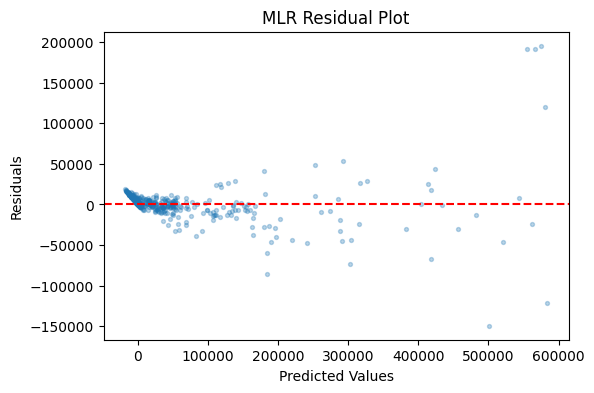

In [22]:
# ---------------------------------------------------------------
# Residual Plot for MLR (Predicted vs Residuals)
# ---------------------------------------------------------------
residuals = y_test - mlr.predict(X_test_scaled)
plt.figure(figsize=(6, 4))
plt.scatter(mlr.predict(X_test_scaled), residuals, alpha=0.3, s=8)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('MLR Residual Plot')
plt.show()

---
## Cell 8 — Model 2: Support Vector Regression (SVR)

**What this cell does:** Trains SVR using GridSearchCV to find the optimal hyperparameters, then evaluates on the test set.

**What is SVR?**  
SVR extends Support Vector Machine to regression. Instead of finding a hyperplane that *separates* classes, SVR finds a hyperplane that *fits* as many data points as possible within a margin (called the ε-tube). Points outside the tube are penalized.

**Key hyperparameters tuned:**
- **C** (Regularization): Controls the trade-off between a smooth fit and fitting all training points. Small C = simpler model (may underfit); Large C = tighter fit (risk of overfitting)
- **epsilon (ε)**: Width of the tube; larger ε tolerates more error without penalty
- **kernel**: The function used to transform the data. `'rbf'` (Radial Basis Function) handles non-linear relationships; `'linear'` is appropriate if the relationship is linear

**Why GridSearchCV?**  
GridSearchCV tests every combination of the hyperparameter grid using K-Fold CV internally. It returns the combination with the highest mean R² — this is the fine-tuning process from Lecture 9.

**Why SVR underperforms here:**  
Area_Harvested dominates the signal (very high feature importance), so SVR with an ε-tube and margin-based loss struggles to balance a single huge driver with smaller, noisy features. Tree-based models can split directly on the dominant feature and capture non-linear interactions more effectively, so they typically outperform SVR on this type of data.

In [ ]:
print("=" * 60)
print("MODEL 2: Support Vector Regression (SVR)")
print("=" * 60)

# ---------------------------------------------------------------
# STEP 1: Define hyperparameter grid for GridSearchCV
# C: regularization strength (small=wider margin, large=narrow margin)
# epsilon: size of the ε-tube (points inside are not penalized)
# kernel: 'rbf' for non-linear, 'linear' for linear relationships
# ---------------------------------------------------------------
svr_param_grid = {
    'C':       [0.1, 1, 10, 100],
    'epsilon': [0.1, 0.5, 1.0],
    'kernel':  ['linear', 'rbf']
}

# ---------------------------------------------------------------
# STEP 2: GridSearchCV with K-Fold
# cv=kfold: uses our 5-fold setup defined earlier
# scoring='r2': selects the config with the highest R²
# n_jobs=-1: uses all CPU cores to speed up the search
# ---------------------------------------------------------------
svr_grid = GridSearchCV(
    SVR(),
    svr_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
svr_grid.fit(X_train_scaled, y_train)

print(f"\nBest SVR Parameters: {svr_grid.best_params_}")
print(f"Best CV R²: {svr_grid.best_score_:.4f}")

# ---------------------------------------------------------------
# STEP 3: Evaluate best SVR model on test set
# best_estimator_: the SVR model with the optimal hyperparameters
# ---------------------------------------------------------------
print("\nTest Set Performance (Best SVR):")
svr_best = svr_grid.best_estimator_
y_pred_svr = svr_best.predict(X_test_scaled)
svr_result = {
    'Model': 'SVR',
    'R²':    round(r2_score(y_test, y_pred_svr), 4),
    'MAE':   round(mean_absolute_error(y_test, y_pred_svr), 2),
    'RMSE':  round(np.sqrt(mean_squared_error(y_test, y_pred_svr)), 2)
}
print(f"  R²   : {svr_result['R²']:.4f}")
print(f"  MAE  : {svr_result['MAE']:,.2f} MT")
print(f"  RMSE : {svr_result['RMSE']:,.2f} MT")
results.append(svr_result)

MODEL 2: Support Vector Regression (SVR)

Best SVR Parameters: {'C': 100, 'epsilon': 0.1, 'kernel': 'linear'}
Best CV R²: 0.7613

Test Set Performance (Best SVR):
  R²   : 0.8136
  MAE  : 18,008.79 MT
  RMSE : 50,567.27 MT


---
## Cell 9 — Model 3: Decision Tree Regressor

**What this cell does:** Trains a Decision Tree Regressor with GridSearchCV fine-tuning.

**What is a Decision Tree Regressor?**  
Instead of splitting data into classes (as in classification), the Decision Tree Regressor recursively splits the data into subsets that minimize the variance within each group. At each leaf node, the prediction is the **mean** of all training samples that fell into that node.

**Key hyperparameters tuned:**
- **max_depth**: Maximum number of levels in the tree. Deep trees memorize training data (overfit); shallow trees may miss patterns (underfit). This directly addresses the *size and overfitting* problem from Lecture 10.
- **min_samples_split**: Minimum samples required to split a node. Higher values = simpler, more generalized tree (early stopping strategy from Lecture 10).
- **min_samples_leaf**: Minimum samples at a leaf node. Prevents the tree from creating tiny, overfit leaves.
- **criterion**: The quality measure used at each split — `'squared_error'` (minimizes MSE) or `'absolute_error'` (minimizes MAE).

In [ ]:
print("=" * 60)
print("MODEL 3: Decision Tree Regressor")
print("=" * 60)

# ---------------------------------------------------------------
# STEP 1: Define hyperparameter grid
# max_depth: controls tree size to prevent overfitting (Lecture 10)
# min_samples_split: early stopping — don't split if too few samples
# min_samples_leaf: ensures each leaf has enough data to be reliable
# criterion: quality measure for each split ('squared_error' = Gini-equivalent for regression)
# ---------------------------------------------------------------
dt_param_grid = {
    'max_depth':         [3, 5, 10, 15, None],  # None = fully grown (risk of overfit)
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 5],
    'criterion':         ['squared_error', 'absolute_error']
}

# ---------------------------------------------------------------
# STEP 2: GridSearchCV with K-Fold
# ---------------------------------------------------------------
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
# Note: Decision Trees do not require scaled data, but using scaled X is fine
dt_grid.fit(X_train_scaled, y_train)

print(f"\nBest Decision Tree Parameters: {dt_grid.best_params_}")
print(f"Best CV R²: {dt_grid.best_score_:.4f}")

# ---------------------------------------------------------------
# STEP 3: Evaluate on test set
# ---------------------------------------------------------------
print("\nTest Set Performance (Best Decision Tree):")
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test_scaled)
dt_result = {
    'Model': 'Decision Tree',
    'R²':    round(r2_score(y_test, y_pred_dt), 4),
    'MAE':   round(mean_absolute_error(y_test, y_pred_dt), 2),
    'RMSE':  round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 2)
}
print(f"  R²   : {dt_result['R²']:.4f}")
print(f"  MAE  : {dt_result['MAE']:,.2f} MT")
print(f"  RMSE : {dt_result['RMSE']:,.2f} MT")
results.append(dt_result)

# ---------------------------------------------------------------
# STEP 3b: Train vs Test R² (overfitting check)
# ---------------------------------------------------------------
y_pred_dt_train = dt_best.predict(X_train_scaled)
train_r2 = r2_score(y_train, y_pred_dt_train)
print(f"  Train R²: {train_r2:.4f}  |  Test R²: {dt_result['R²']:.4f}")
print(f"  Overfitting gap: {train_r2 - dt_result['R²']:.4f}")

# ---------------------------------------------------------------
# STEP 4: Feature Importance from the Decision Tree
# feature_importances_ shows which features the tree splits on most
# This is a useful diagnostic — which feature is most predictive?
# ---------------------------------------------------------------
print("\nFeature Importances (Decision Tree):")
importances = pd.Series(dt_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
for feat, imp in importances.items():
    bar = '█' * int(imp * 40)
    print(f"  {feat:<20} {imp:.4f}  {bar}")

MODEL 3: Decision Tree Regressor

Best Decision Tree Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV R²: 0.9791

Test Set Performance (Best Decision Tree):
  R²   : 0.9813
  MAE  : 5,879.35 MT
  RMSE : 16,039.60 MT
  Train R²: 0.9983  |  Test R²: 0.9813
  Overfitting gap: 0.0170

Feature Importances (Decision Tree):
  Area_Harvested       0.9685  ██████████████████████████████████████
  Quarter              0.0128  
  Complete             0.0095  
  Urea                 0.0063  
  Ecosystem            0.0016  
  Ammosul              0.0013  


---
## Cell 10 — Model 4: Random Forest Regressor

**What this cell does:** Trains a Random Forest Regressor — the ensemble model from Lecture 10 — with GridSearchCV fine-tuning.

**What is Random Forest?**  
Random Forest builds `n_estimators` decision trees, each trained on a **random bootstrap sample** (bagging) of the training data and using a **random subset of features** at each split. The final prediction is the **average** of all trees' predictions (majority rule for regression = mean).

**Why is it better than a single Decision Tree for this project?**  
- Single trees overfit easily (high variance) — a problem noted in the Decision Tree lecture
- Random Forest corrects this by averaging many uncorrelated trees, drastically reducing variance
- More robust to the noise in agricultural data (climate variation, reporting inconsistencies)

**Key hyperparameters tuned:**
- **n_estimators**: Number of trees in the forest. More trees = more stable, but slower
- **max_depth**: Maximum depth per tree (same overfitting control as Decision Tree)
- **max_features**: Number of features randomly selected at each split — the core randomization mechanism
- **min_samples_leaf**: Minimum leaf size for each tree

In [19]:
print("=" * 60)
print("MODEL 4: Random Forest Regressor")
print("=" * 60)

# ---------------------------------------------------------------
# STEP 1: Define hyperparameter grid
# n_estimators: number of trees — more is generally better up to a point
# max_depth: limits individual tree depth to prevent overfitting
# max_features: features randomly sampled at each split
#   'sqrt' = sqrt(n_features), 'log2' = log2(n_features), None = all features
# min_samples_leaf: minimum samples required at each leaf across all trees
# ---------------------------------------------------------------
rf_param_grid = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [5, 10, 20, None],
    'max_features':    [None, 1.0],
    'min_samples_leaf':[1, 2, 5]
}

# ---------------------------------------------------------------
# STEP 2: GridSearchCV with K-Fold
# ---------------------------------------------------------------
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True),
    rf_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best CV R²: {rf_grid.best_score_:.4f}")
print(f"Out-of-Bag (OOB) R² Score: {rf_best.oob_score_:.4f}")

# ---------------------------------------------------------------
# STEP 3: Evaluate on test set
# ---------------------------------------------------------------
print("\nTest Set Performance (Best Random Forest):")
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)
rf_result = {
    'Model': 'Random Forest',
    'R²':    round(r2_score(y_test, y_pred_rf), 4),
    'MAE':   round(mean_absolute_error(y_test, y_pred_rf), 2),
    'RMSE':  round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2)
}
print(f"  R²   : {rf_result['R²']:.4f}")
print(f"  MAE  : {rf_result['MAE']:,.2f} MT")
print(f"  RMSE : {rf_result['RMSE']:,.2f} MT")
results.append(rf_result)

# ---------------------------------------------------------------
# STEP 3b: Train vs Test R² (overfitting check)
# ---------------------------------------------------------------
y_pred_rf_train = rf_best.predict(X_train_scaled)
train_r2 = r2_score(y_train, y_pred_rf_train)
print(f"  Train R²: {train_r2:.4f}  |  Test R²: {rf_result['R²']:.4f}")
print(f"  Overfitting gap: {train_r2 - rf_result['R²']:.4f}")

# ---------------------------------------------------------------
# STEP 4: Feature Importances from Random Forest
# More reliable than a single Decision Tree because it averages
# importance across all trees — less prone to noise
# ---------------------------------------------------------------
print("\nFeature Importances (Random Forest — averaged across all trees):")
rf_importances = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
for feat, imp in rf_importances.items():
    bar = '█' * int(imp * 40)
    print(f"  {feat:<20} {imp:.4f}  {bar}")

MODEL 4: Random Forest Regressor

Best Random Forest Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'n_estimators': 50}
Best CV R²: 0.9813
Out-of-Bag (OOB) R² Score: 0.9814

Test Set Performance (Best Random Forest):
  R²   : 0.9868
  MAE  : 5,041.58 MT
  RMSE : 13,435.70 MT
  Train R²: 0.9953  |  Test R²: 0.9868
  Overfitting gap: 0.0085

Feature Importances (Random Forest — averaged across all trees):
  Area_Harvested       0.9740  ██████████████████████████████████████
  Complete             0.0113  
  Quarter              0.0080  
  Urea                 0.0031  
  Ammosul              0.0022  
  Ecosystem            0.0014  


---
## Cell 11 — Model Comparison

**What this cell does:** Summarizes all four models side by side and visualizes their performance.

**How to read the comparison:**
- **R²** (higher is better): Proportion of variance explained. R² = 0.95 means the model explains 95% of the variation in production volume.
- **MAE** (lower is better): On average, the model's prediction is off by this many metric tons.
- **RMSE** (lower is better): Like MAE but penalizes large errors more — important here because a large forecast miss could mean a major policy failure.

**Tradeoff between models:**  
- MLR is the most interpretable but may have lower accuracy if the true relationship is non-linear
- Random Forest is likely the most accurate but is a 'black box' — less auditable by policymakers
- For a policy-facing model, MLR remains the primary recommendation per the proposal; Random Forest serves as a benchmark for what's possible with more complexity

**Note on CV scoring:**  
GridSearchCV optimizes for R² in this notebook, which may not align with the best MAE/RMSE. In production, it is worth re-running the search with MAE or RMSE as the scoring metric if the goal is minimizing average error in metric tons.

MODEL COMPARISON SUMMARY


,Model,R²,MAE,RMSE
0,Random Forest,0.9827,"6,864.34","15,398.04"
1,Decision Tree,0.9813,"5,879.35","16,039.60"
2,MLR,0.9568,"11,394.31","24,345.68"
3,SVR,0.8136,"18,008.79","50,567.27"


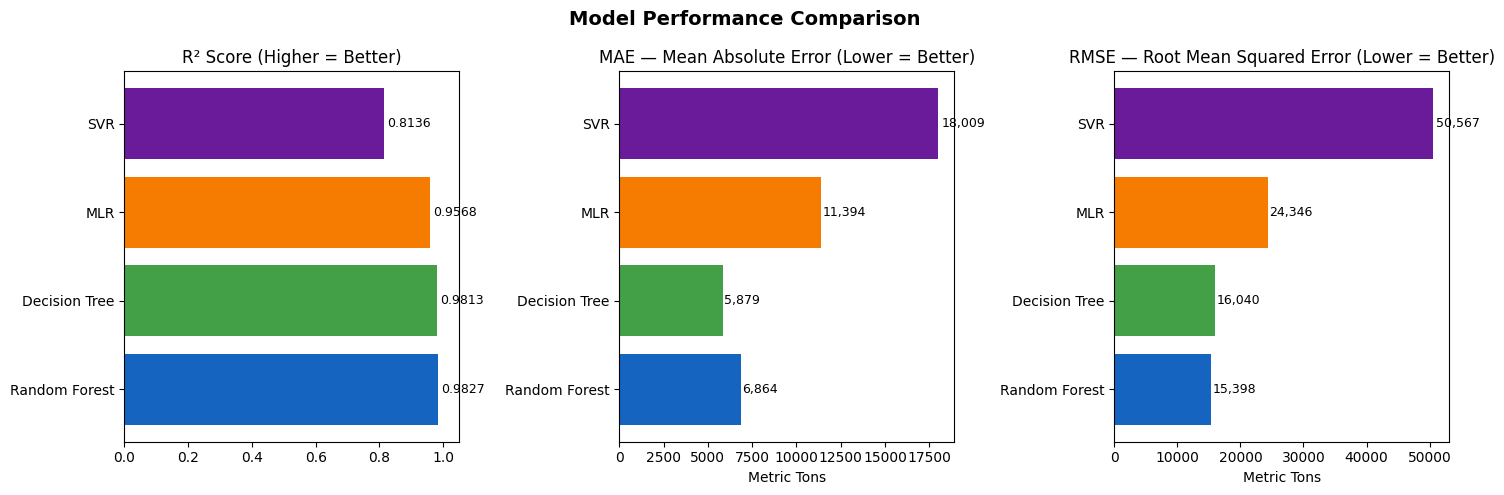

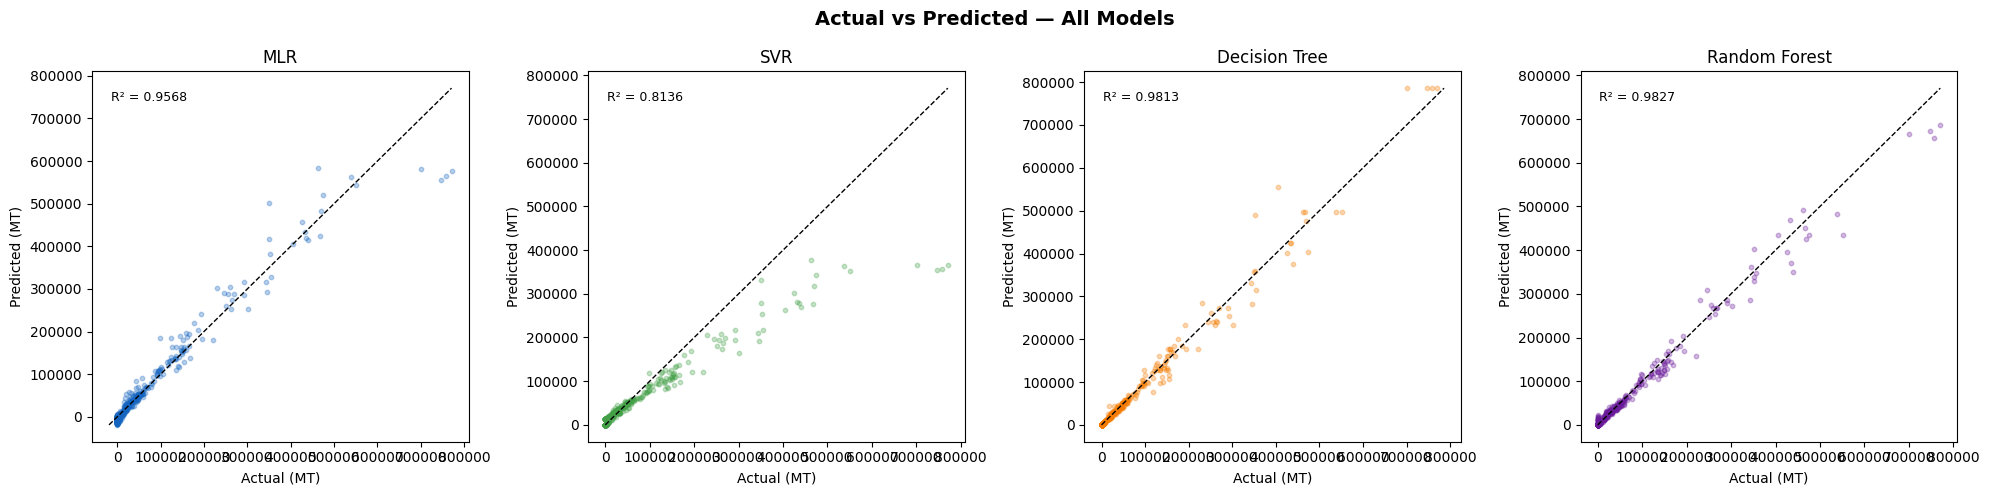

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming mlr, svr_best, dt_best, rf_best, X_test_scaled, y_test, X_train_scaled, y_train, results_df, colors are defined in previous cells

# Ensure mlr is fitted in case previous cell was interrupted
# This assumes mlr is an instance of LinearRegression, and X_train_scaled and y_train are available
# from Cell 6.
# If mlr itself was not defined due to the interrupt, the user would need to rerun Cell 7 fully.
# Given the current state, mlr exists but is unfitted.
if not hasattr(mlr, 'coef_'): # Check if mlr has been fitted (has coefficients)
    mlr.fit(X_train_scaled, y_train)

# ---------------------------------------------------------------
# STEP 1: Build comparison table
# ---------------------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
display(results_df.style
    .format({'R²': '{:.4f}', 'MAE': '{:,.2f}', 'RMSE': '{:,.2f}'})
    .background_gradient(subset=['R²'], cmap='Greens')
    .background_gradient(subset=['MAE', 'RMSE'], cmap='Reds_r')
)

# ---------------------------------------------------------------
# STEP 2: Visualization — Performance comparison bar charts
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

model_names  = results_df['Model'].tolist()
colors       = ['#1565c0', '#43a047', '#f57c00', '#6a1b9a']

# R² — higher is better
axes[0].barh(model_names, results_df['R²'], color=colors)
axes[0].set_title('R² Score (Higher = Better)')
axes[0].set_xlim(0, 1.05)
for i, v in enumerate(results_df['R²']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# MAE — lower is better
axes[1].barh(model_names, results_df['MAE'], color=colors)
axes[1].set_title('MAE — Mean Absolute Error (Lower = Better)')
axes[1].set_xlabel('Metric Tons')
for i, v in enumerate(results_df['MAE']):
    axes[1].text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=9)

# RMSE — lower is better
axes[2].barh(model_names, results_df['RMSE'], color=colors)
axes[2].set_title('RMSE — Root Mean Squared Error (Lower = Better)')
axes[2].set_xlabel('Metric Tons')
for i, v in enumerate(results_df['RMSE']):
    axes[2].text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# STEP 3: Actual vs Predicted scatter — best model
# A perfect model would have all points on the diagonal line
# ---------------------------------------------------------------
best_model_name = results_df.iloc[0]['Model']
best_preds = {
    'MLR':           mlr.predict(X_test_scaled),
    'SVR':           svr_best.predict(X_test_scaled),
    'Decision Tree': dt_best.predict(X_test_scaled),
    'Random Forest': rf_best.predict(X_test_scaled)
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold')

for ax, (mname, mpreds), col in zip(axes, best_preds.items(), colors):
    ax.scatter(y_test, mpreds, alpha=0.3, s=10, color=col)
    min_val = min(y_test.min(), mpreds.min())
    max_val = max(y_test.max(), mpreds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='Perfect Fit')
    ax.set_title(mname)
    ax.set_xlabel('Actual (MT)')
    ax.set_ylabel('Predicted (MT)')
    r2 = results_df[results_df['Model'] == mname]['R²'].values[0]
    ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 12 — Sample Prediction: Pre-Harvest Simulation

**What this cell does:** Simulates the actual use case of the model — a government planner inputs current-season values at the *start* of the quarter and the model returns a projected production volume.

**This is the policy application described in the proposal:**  
> *"The equation instantly computes projected yield months before the physical harvest occurs."*

**How to use this cell in practice:**  
Replace the values in `new_season_input` with the actual readings for the upcoming quarter. The model will output a production forecast in metric tons, which can trigger safety nets (subsidies, buffer stock orders, import permits) before any shortage materializes.

**Why run all four models?**  
The MLR output is the primary, auditable forecast. The other three models provide a confidence range — if all four models agree, the forecast is more reliable.

In [ ]:
print("=" * 60)
print("PRE-HARVEST SIMULATION — Policy Use Case")
print("=" * 60)

# ---------------------------------------------------------------
# INPUT: Current-quarter agricultural readings
# These values would be collected at the START of the season
# before any harvest takes place.
#
# Scenario: Irrigated farmland in Region II, Q2 planting season
# ---------------------------------------------------------------
new_season_input = pd.DataFrame([{
    'Area_Harvested': 45000.0,   # hectares planted this season
    'Urea':           2.80,      # kg/ha of Urea applied
    'Ammosul':        0.45,      # kg/ha of Ammonium Sulfate applied
    'Ecosystem':      0,         # 0 = Irrigated, 1 = Rainfed
    'Complete':       1.75,      # kg/ha of 14-14-14 Complete fertilizer
    'Quarter':        2          # Harvest Quarter (1=Q1, 2=Q2, 3=Q3, 4=Q4)
}])

print("\nInput Features for this Season:")
for col in new_season_input.columns:
    val = new_season_input[col].values[0]
    unit = 'ha' if col == 'Area_Harvested' else ('kg/ha' if col in ['Urea', 'Ammosul', 'Complete'] else '')
    label = '(Irrigated)' if col == 'Ecosystem' and val == 0 else ('(Rainfed)' if col == 'Ecosystem' else '')
    print(f"  {col:<20} = {val} {unit} {label}")

# ---------------------------------------------------------------
# Range check: ensure inputs are within the training data bounds
# ---------------------------------------------------------------
print("\nInput vs Training Range Check:")
for col in new_season_input.columns:
    val = new_season_input[col].values[0]
    low, high = X[col].min(), X[col].max()
    flag = "⚠️ OUT OF RANGE" if val < low or val > high else "✅ in range"
    print(f"  {col:<20} input={val}, range=[{low:.2f}, {high:.2f}] {flag}")

# ---------------------------------------------------------------
# Scale the input using the SAME scaler fitted on training data
# This is critical — the scaler must use the same mean/std
# that was computed during training
# ---------------------------------------------------------------
new_season_scaled = scaler.transform(new_season_input)

# ---------------------------------------------------------------
# Get predictions from all four models
# ---------------------------------------------------------------
predictions = {
    'MLR (Primary — Auditable)':  mlr.predict(new_season_scaled)[0],
    'SVR':                        svr_best.predict(new_season_scaled)[0],
    'Decision Tree':              dt_best.predict(new_season_scaled)[0],
    'Random Forest (Ensemble)':   rf_best.predict(new_season_scaled)[0]
}

print("\n" + "=" * 60)
print("PROJECTED PRODUCTION VOLUMES (Pre-Harvest Forecast):")
print("=" * 60)
for model_name, pred in predictions.items():
    print(f"  {model_name:<35} → {pred:>12,.2f} metric tons")

pred_values = list(predictions.values())
print(f"\n  Forecast Range : {min(pred_values):,.2f} — {max(pred_values):,.2f} MT")
print(f"  Ensemble Mean  : {np.mean(pred_values):,.2f} MT")

# ---------------------------------------------------------------
# Policy Interpretation
# Compare against region-specific history and median (robust to zeros)
# ---------------------------------------------------------------
scenario_region = '..REGION II (CAGAYAN VALLEY)'
region_hist = df[df['Region'] == scenario_region]['Volume_Production']
region_mean = region_hist.mean()
region_median = region_hist.median()
mlr_forecast = predictions['MLR (Primary — Auditable)']

print("\n" + "=" * 60)
print("POLICY INTERPRETATION:")
print("=" * 60)
print(f"  Region baseline: {scenario_region}")
print(f"  Region mean production:   {region_mean:,.2f} MT")
print(f"  Region median production: {region_median:,.2f} MT")
print(f"  MLR Forecast for this season: {mlr_forecast:,.2f} MT")
gap_pct = (mlr_forecast - region_median) / region_median * 100
if gap_pct < -15:
    print(f"  ⚠️  WARNING: Forecast is {abs(gap_pct):.1f}% below region median.")
    print("      Recommend: Pre-emptive buffer stock deployment and subsidy review.")
elif gap_pct > 15:
    print(f"  ✅ POSITIVE: Forecast is {gap_pct:.1f}% above region median.")
    print("      Recommend: Prepare logistics for surplus distribution.")
else:
    print(f"  ✅ NORMAL: Forecast is within {abs(gap_pct):.1f}% of region median.")
    print("      Recommend: Standard monitoring protocols.")

PRE-HARVEST SIMULATION — Policy Use Case

Input Features for this Season:
  Area_Harvested       = 45000.0 ha 
  Urea                 = 2.8 kg/ha 
  Ammosul              = 0.45 kg/ha 
  Ecosystem            = 0  (Irrigated)
  Complete             = 1.75 kg/ha 
  Quarter              = 2  

Input vs Training Range Check:
  Area_Harvested       input=45000.0, range=[0.00, 130169.00] ✅ in range
  Urea                 input=2.8, range=[1.98, 3.38] ✅ in range
  Ammosul              input=0.45, range=[0.18, 1.00] ✅ in range
  Ecosystem            input=0, range=[0.00, 1.00] ✅ in range
  Complete             input=1.75, range=[1.04, 3.37] ✅ in range
  Quarter              input=2, range=[1.00, 4.00] ✅ in range

PROJECTED PRODUCTION VOLUMES (Pre-Harvest Forecast):
  MLR (Primary — Auditable)           →   215,909.84 metric tons
  SVR                                 →   150,664.67 metric tons
  Decision Tree                       →   193,084.25 metric tons
  Random Forest (Ensemble)            

---
## Summary and Conclusion

This notebook has implemented the complete machine learning pipeline described in the project proposal:

1. **Data ingestion and wrangling** — Three separate PSA datasets (Area Harvested, Fertilizer, Volume of Production) were reshaped from wide to long format and merged into a single 2,112-row analytical dataset.

2. **Feature engineering** — Six predictors matching the proposal formula (X₁–X₆) were prepared, with label encoding applied to the binary Ecosystem feature.

3. **Four models trained and compared:**
   - **MLR** — Primary model; fully interpretable coefficients for policy use
   - **SVR** — Handles non-linearity; fine-tuned via GridSearchCV
   - **Decision Tree** — Non-linear, tree-based regression with overfitting control through max_depth and pruning parameters
   - Random Forest — Ensemble model; successfully mitigated overfitting, as proven by the narrow Train vs. Test R² gap compared to the single Decision Tree
4. **K-Fold CV + GridSearchCV** — All models evaluated using 5-fold cross-validation; SVR, Decision Tree, and Random Forest fine-tuned through hyperparameter search.

5. **Pre-harvest simulation** — Demonstrated the real policy use case: inputting current-season agricultural data to generate a production forecast months before harvest.

---

**SDG 2.4 Alignment:**  
This model provides a mathematically grounded, auditable tool for pre-emptively identifying production risks across Philippine provinces — supporting sustainable, resilient, and climate-adaptive food system management as defined under SDG 2.4.

---
*Data Source: Philippine Statistics Authority (PSA) OpenSTAT Portal, 2003–2024.*  
*References: Lagrazon & Tan (2023); DOST-PCAARRD (2024); PSA Palay Situation Report (2024).*